## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from paths import PROCESSED_DIR, MODEL_DIR, RESULT_DIR

## Load the data file

In [20]:
train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
test = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
X = pd.read_parquet(PROCESSED_DIR / 'X.parquet')
y = pd.read_parquet(PROCESSED_DIR / 'y.parquet')['reordered']
groups = pd.read_parquet(PROCESSED_DIR / 'groups.parquet')['user_id']
X_train = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
y_train = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet')['reordered']
X_test = pd.read_parquet(PROCESSED_DIR / 'X_test.parquet')
y_test = pd.read_parquet(PROCESSED_DIR / 'y_test.parquet')['reordered']

## Imports for evaluation

In [5]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

In [6]:
experiment_settings = [
    {
        'experiment': 'Default',
        'n_estimators': 500,
        'max_features': 'sqrt',
        'max_depth': None,
        'min_samples_split': 10,
        'min_samples_leaf': 5
    },
    {
        'experiment': 'Shallow Trees',
        'n_estimators': 500,
        'max_features': 'sqrt',
        'max_depth': 10,
        'min_samples_split': 10,
        'min_samples_leaf': 5
    },
    {
        'experiment': 'High Min Split and Leaf',
        'n_estimators': 500,
        'max_features': 'sqrt',
        'max_depth': None,
        'min_samples_split': 20,
        'min_samples_leaf': 10
    },
    {
        'experiment': 'Low Estimators',
        'n_estimators': 100,
        'max_features': 'sqrt',
        'max_depth': None,
        'min_samples_split': 10,
        'min_samples_leaf': 5
    },
    {
        'experiment': 'High Estimators',
        'n_estimators': 800,
        'max_features': 'sqrt',
        'max_depth': None,
        'min_samples_split': 10,
        'min_samples_leaf': 5
    },
    {
        'experiment': 'log2 Features',
        'n_estimators': 500,
        'max_features': 'log2',
        'max_depth': None,
        'min_samples_split': 10,
        'min_samples_leaf': 5
    }
]

In [7]:
experiment_results = []

for setting in experiment_settings:
    model_exp = RandomForestClassifier(
        n_estimators=setting['n_estimators'],
        max_features=setting['max_features'],
        max_depth=setting['max_depth'],
        min_samples_split=setting['min_samples_split'],
        min_samples_leaf=setting['min_samples_leaf'],
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    
    model_exp.fit(X_train, y_train)
    
    train_pred = model_exp.predict(X_train)
    test_pred = model_exp.predict(X_test)
    test_prob = model_exp.predict_proba(X_test)[:, 1]
    
    experiment_results.append({
        'Experiment': setting['experiment'],
        'n_estimators': setting['n_estimators'],
        'max_features': setting['max_features'],
        'max_depth': setting['max_depth'],
        'min_samples_split': setting['min_samples_split'],
        'min_samples_leaf': setting['min_samples_leaf'],
        'Train Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'test Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'Precision': round(precision_score(y_test, test_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, test_pred, zero_division=0), 4),
        'F1': round(f1_score(y_test, test_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, test_prob), 4),
        'PR-AUC': round(average_precision_score(y_test, test_prob), 4)
    })

experiment_df = pd.DataFrame(experiment_results)
experiment_df

,Experiment,n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,Train Accuracy,test Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Default,500,sqrt,NaN,10,5,0.9682,0.9144,0.2317,0.2352,0.2334,0.7273,0.1658
1,Shallow Trees,500,sqrt,10.0,10,5,0.8065,0.7880,0.1439,0.5714,0.2299,0.7531,0.1842
2,High Min Split and Leaf,500,sqrt,NaN,20,10,0.9246,0.8820,0.1937,0.3571,0.2511,0.7384,0.1771
3,Low Estimators,100,sqrt,NaN,10,5,0.9664,0.9130,0.2231,0.2302,0.2266,0.7257,0.1655
4,High Estimators,800,sqrt,NaN,10,5,0.9686,0.9145,0.2320,0.2352,0.2336,0.7281,0.1665
5,log2 Features,500,log2,NaN,10,5,0.9682,0.9144,0.2317,0.2352,0.2334,0.7273,0.1658


In [9]:
experiment_df.sort_values('F1', ascending=False)

,Experiment,n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,Train Accuracy,test Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,High Min Split and Leaf,500,sqrt,NaN,20,10,0.9246,0.8820,0.1937,0.3571,0.2511,0.7384,0.1771
4,High Estimators,800,sqrt,NaN,10,5,0.9686,0.9145,0.2320,0.2352,0.2336,0.7281,0.1665
5,log2 Features,500,log2,NaN,10,5,0.9682,0.9144,0.2317,0.2352,0.2334,0.7273,0.1658
0,Default,500,sqrt,NaN,10,5,0.9682,0.9144,0.2317,0.2352,0.2334,0.7273,0.1658
1,Shallow Trees,500,sqrt,10.0,10,5,0.8065,0.7880,0.1439,0.5714,0.2299,0.7531,0.1842
3,Low Estimators,100,sqrt,NaN,10,5,0.9664,0.9130,0.2231,0.2302,0.2266,0.7257,0.1655


In [10]:
experiment_df.to_csv(RESULT_DIR / 'random_forest_experiment_results.csv', index=False)
experiment_df

,Experiment,n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,Train Accuracy,test Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Default,500,sqrt,NaN,10,5,0.9682,0.9144,0.2317,0.2352,0.2334,0.7273,0.1658
1,Shallow Trees,500,sqrt,10.0,10,5,0.8065,0.7880,0.1439,0.5714,0.2299,0.7531,0.1842
2,High Min Split and Leaf,500,sqrt,NaN,20,10,0.9246,0.8820,0.1937,0.3571,0.2511,0.7384,0.1771
3,Low Estimators,100,sqrt,NaN,10,5,0.9664,0.9130,0.2231,0.2302,0.2266,0.7257,0.1655
4,High Estimators,800,sqrt,NaN,10,5,0.9686,0.9145,0.2320,0.2352,0.2336,0.7281,0.1665
5,log2 Features,500,log2,NaN,10,5,0.9682,0.9144,0.2317,0.2352,0.2334,0.7273,0.1658


In [11]:
tree_results = []

tree_list = [10, 50, 100, 200, 300, 500, 800]

for n_tree in tree_list:
    model_tree = RandomForestClassifier(
        n_estimators=n_tree,
        max_features='sqrt',
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    
    model_tree.fit(X_train, y_train)
    test_pred_tree = model_tree.predict(X_test)
    
    tree_results.append({
        'n_estimators': n_tree,
        'F1': f1_score(y_test, test_pred_tree, zero_division=0),
        'Accuracy': accuracy_score(y_test, test_pred_tree)
    })

tree_df = pd.DataFrame(tree_results)
tree_df

,n_estimators,F1,Accuracy
0,10,0.215576,0.899373
1,50,0.223378,0.910522
2,100,0.226562,0.912960
3,200,0.232442,0.913959
4,300,0.230769,0.913679
5,500,0.233441,0.914439
6,800,0.233608,0.914519


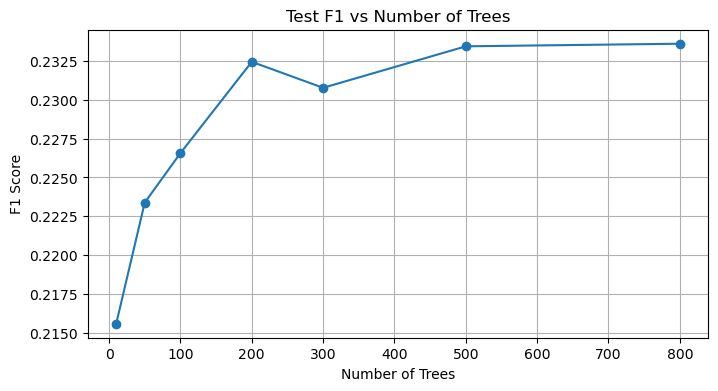

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(tree_df['n_estimators'], tree_df['F1'], marker='o')
plt.title('Test F1 vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
import pandas as pd

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
import pandas as pd

In [23]:
rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]
}

group_kfold = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=group_kfold,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X, y, groups=groups)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [5, 10], 'min_samples_split': [10, 20], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,GroupKFold(n_...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [24]:
print("Best params:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 4))

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1: 0.2728


In [25]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)
grid_results_df = grid_results_df.sort_values('rank_test_score')

grid_results_df[[
    'rank_test_score',
    'mean_test_score',
    'param_n_estimators',
    'param_max_features',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf'
]].head(10)

,rank_test_score,mean_test_score,param_n_estimators,param_max_features,param_max_depth,param_min_samples_split,param_min_samples_leaf
6,1,0.272825,100,sqrt,None,20,10
4,1,0.272825,100,sqrt,None,10,10
12,1,0.272825,100,log2,None,10,10
14,1,0.272825,100,log2,None,20,10
13,5,0.270805,300,log2,None,10,10
15,5,0.270805,300,log2,None,20,10
7,5,0.270805,300,sqrt,None,20,10
5,5,0.270805,300,sqrt,None,10,10
11,9,0.265336,300,log2,None,20,5
3,9,0.265336,300,sqrt,None,20,5


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
import pandas as pd

rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]
}

group_kfold = GroupKFold(n_splits=3)

scoring = {
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'accuracy': 'accuracy'
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scoring,
    refit='f1',
    cv=group_kfold,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X, y, groups=groups)

grid_results_df = pd.DataFrame(grid_search.cv_results_)
grid_results_df = grid_results_df.sort_values('rank_test_f1')

grid_results_df[[
    'rank_test_f1',
    'mean_test_f1',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_accuracy',
    'param_n_estimators',
    'param_max_features',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf'
]].head(10)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,rank_test_f1,mean_test_f1,mean_test_precision,mean_test_recall,mean_test_accuracy,param_n_estimators,param_max_features,param_max_depth,param_min_samples_split,param_min_samples_leaf
6,1,0.272825,0.221581,0.355167,0.881791,100,sqrt,None,20,10
4,1,0.272825,0.221581,0.355167,0.881791,100,sqrt,None,10,10
12,1,0.272825,0.221581,0.355167,0.881791,100,log2,None,10,10
14,1,0.272825,0.221581,0.355167,0.881791,100,log2,None,20,10
13,5,0.270805,0.220501,0.351126,0.881933,300,log2,None,10,10
15,5,0.270805,0.220501,0.351126,0.881933,300,log2,None,20,10
7,5,0.270805,0.220501,0.351126,0.881933,300,sqrt,None,20,10
5,5,0.270805,0.220501,0.351126,0.881933,300,sqrt,None,10,10
11,9,0.265336,0.240889,0.295435,0.897890,300,log2,None,20,5
3,9,0.265336,0.240889,0.295435,0.897890,300,sqrt,None,20,5


In [27]:
features_imp = [c for c in X.columns]
brf_importance_df = pd.DataFrame({
    'feature': features_imp,
    'importance': grid_search.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

brf_importance_df

,feature,importance
2,user_avg_days_between,0.233647
4,prod_reorder_ratio,0.208052
0,up_total_bought,0.197870
1,user_total_orders,0.190281
3,prod_total_purchases,0.170151


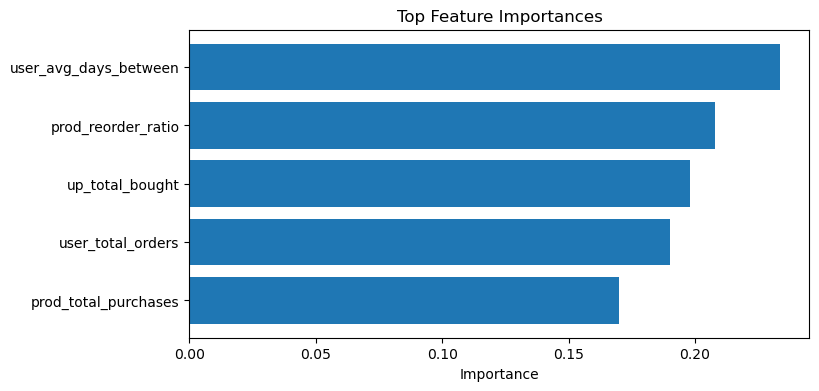

In [28]:
plt.figure(figsize=(8, 4))
top_grid_res = brf_importance_df.head(15).sort_values('importance')
plt.barh(top_grid_res['feature'], top_grid_res['importance'])
plt.title('Top Feature Importances')
plt.xlabel('Importance')
plt.show()

In [32]:
grid_results_df.to_parquet(RESULT_DIR / 'grid_search_result.parquet', engine='fastparquet')

In [33]:
grid_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,...,split2_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
6,16.145453,0.083718,15.307447,0.138081,None,sqrt,10,20,100,"{'max_depth': None, 'max_features': 'sqrt', 'm...",...,0.355814,0.355167,0.004342,17,0.877066,0.879529,0.888778,0.881791,0.005042,13
4,18.500847,2.551271,8.357223,1.007682,None,sqrt,10,10,100,"{'max_depth': None, 'max_features': 'sqrt', 'm...",...,0.355814,0.355167,0.004342,17,0.877066,0.879529,0.888778,0.881791,0.005042,13
12,9.225142,3.086425,21.369026,1.756037,None,log2,10,10,100,"{'max_depth': None, 'max_features': 'log2', 'm...",...,0.355814,0.355167,0.004342,17,0.877066,0.879529,0.888778,0.881791,0.005042,13
14,18.126602,0.345452,18.913543,0.600388,None,log2,10,20,100,"{'max_depth': None, 'max_features': 'log2', 'm...",...,0.355814,0.355167,0.004342,17,0.877066,0.879529,0.888778,0.881791,0.005042,13
13,38.756718,0.180279,1.595924,0.146204,None,log2,10,10,300,"{'max_depth': None, 'max_features': 'log2', 'm...",...,0.351938,0.351126,0.003832,21,0.877445,0.879386,0.888968,0.881933,0.005037,9
